# Routine to calculate vertical PDF of cloud top heigh from ZM convection
## Intended to examine impact of ZM KE parcel changes

In [1]:
import numpy as np
import matplotlib.pyplot as mp
import xarray as xr
import pandas as pd
import glob
import seaborn as sbn

from distributed import Client, LocalCluster
from ncar_jobqueue import NCARCluster

print(xr.__version__)

2024.10.0


In [2]:
# DASK

cluster = NCARCluster(project='P93300642',interface='ext', job_extra_directives=[],walltime ='12:00:00')
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/34689/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/34689/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.94:36271,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/34689/status,Total threads: 0
Started: Just now,Total memory: 0 B


Task exception was never retrieved
future: <Task finished name='Task-989' coro=<Client._gather.<locals>.wait() done, defined at /glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/client.py:2395> exception=AllExit()>
Traceback (most recent call last):
  File "/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/client.py", line 2404, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-990' coro=<Client._gather.<locals>.wait() done, defined at /glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/client.py:2395> exception=AllExit()>
Traceback (most recent call last):
  File "/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/client.py", line 2404, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task

In [7]:
# Read files #

cases = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a',
         'f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b' ]

cnames = ['CAM7','CAM7+KE']


dir_in = ['s','s','s','s'] # s-scracth, c-campaign


lat_bounds = slice(30, 50)  # Latitude range
lon_bounds = slice(95, 135)  # Longitude range
time_range = slice("1995-01-01", "1995-01-31")  # Time range

#lat_bounds = slice(0, 10)  # Latitude range
#lon_bounds = slice(90, 120)  # Longitude range
#time_range = slice("2010-01-01", "2010-01-31")  # Time range


season0 = 'DJF'
vpscale = 86400.*1000.

vname = 'PCONVT' ; vscale = 0.01 ; vunits = 'Pressure of Convective Tops' ; ylims = [1000.,50.] ; xlims = [1000.,50.] ; bwidth=20
#vname = 'FLUT' ; vscale = 1. ; vunits = 'Outgoing Long-wave Radiation (W/m^2)' ; ylims = [1000.,50.] ; xlims = [300.,100.] ; bwidth=5

fdir_c = '/glade/campaign/cgd/amp/amwg/runs/'
fdir_s = '/glade/derecho/scratch/rneale/'





CASE =  f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a
/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a*h1a*1995*nc
[[[8.18547793e-03 3.80736543e-03 1.12863612e-08 ... 5.71272016e-01
   1.01784813e+00 3.07418919e+00]
  [1.32991334e-08 1.00419051e-08 6.99311919e-12 ... 1.68491200e-01
   9.44551229e-01 3.39052701e+00]
  [5.00443003e-13 1.50314689e-12 3.80179910e-13 ... 2.81836361e-01
   5.99864364e-01 1.50321460e+00]
  ...
  [1.27344357e-03 1.14075644e-02 2.94532739e-02 ... 3.20019992e-03
   8.34528706e-04 3.39445076e-03]
  [1.02235004e-02 4.37964983e-02 7.59900510e-02 ... 3.69237969e-03
   6.28188951e-04 2.96501326e-04]
  [4.69902791e-02 1.23276033e-01 1.27587229e-01 ... 2.76003056e-03
   1.52318506e-03 3.06489016e-03]]

 [[1.54384285e-01 2.16554165e-01 2.62097362e-02 ... 6.13596737e-01
   9.14812982e-01 2.67551804e+00]
  [1.05643220e-01 1.13876380e-01 6.86615705e-02 ... 2.73497015e-01
   9.56145585e-01 3.41541076e+00]

OSError: no files to open

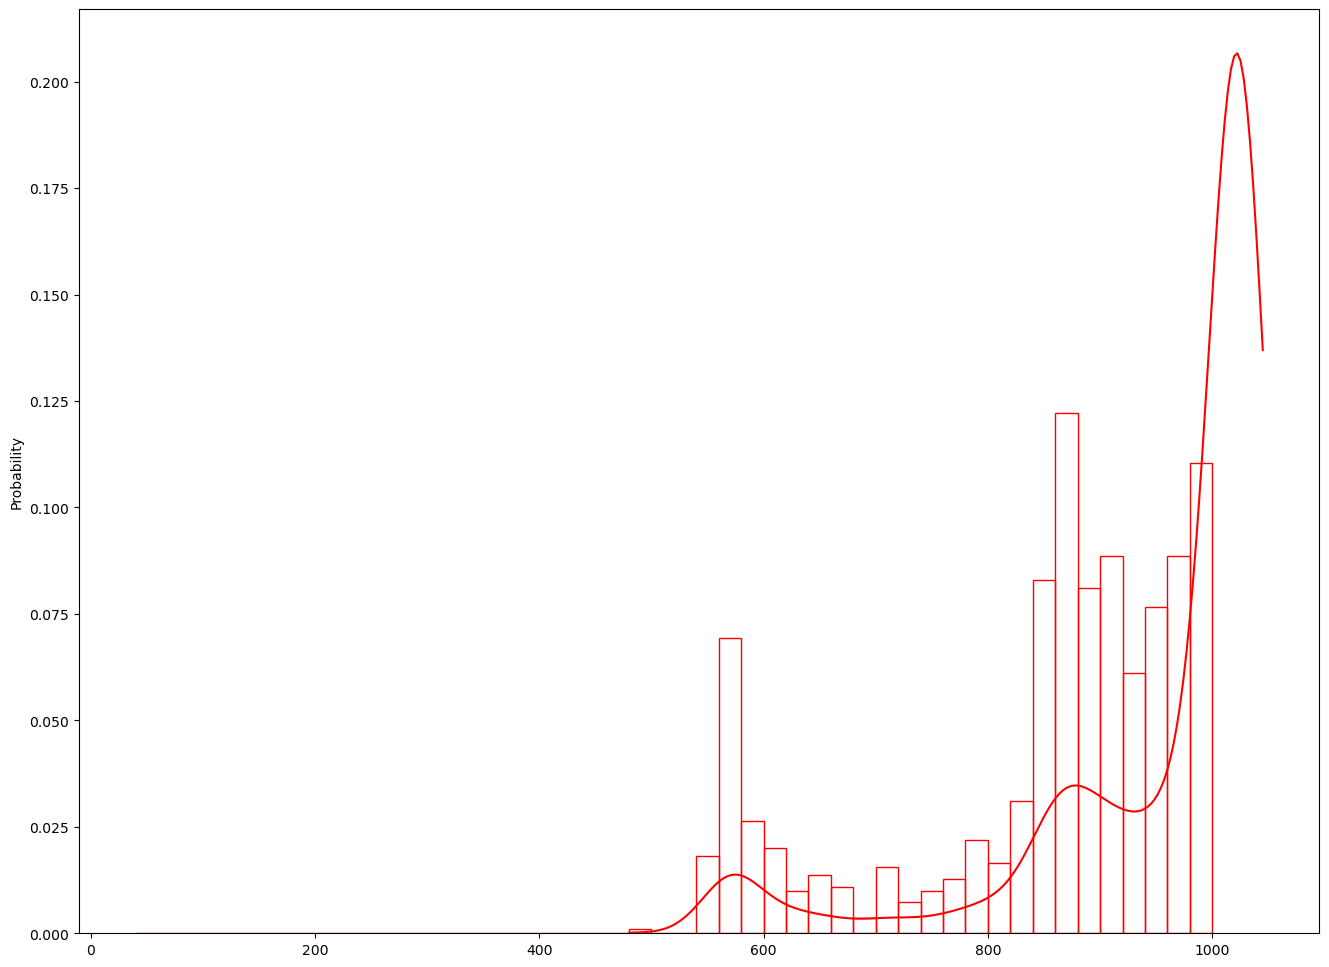

In [8]:
# PLOT HISTOGRAM #

plt1, ax1 = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases
#sbn.color_palette("colorblind")
#colors = ['olive','coral','purple']
colors = ['red','blue','cyan','purple']

for ic,case in enumerate(cases):

    
    print()
    print('CASE = ',case)
    
    if ic > 10:
        ffile0 = fdir_s+case+'/run/'+case
    else:
        ffile0 = fdir_s+'archive/'+cases[ic]+'/atm/hist/'+case
    
    
#    ffile = ffile0+'*h3i*2010*nc'
    ffile = ffile0+'*h1a*1995*nc'
    
    
    print(ffile)
    flist  = sorted(glob.glob(ffile))
    fhist  =  xr.open_mfdataset(flist,parallel=True)  
    fhist  = fhist.sel(lat=lat_bounds, lon=lon_bounds, time=time_range)


    
    fvar = fhist[vname]
    vlong =  fvar.attrs['long_name']    
    fvar = vscale*fvar

    fprecc = fhist['PRECT']
    fprecc = vpscale*fprecc

    
    print(fprecc[0:100].values)
    
    # Mask
    fvar = fvar.where(fprecc > 1.)
    
    # 1d-ize
    pvar_1d = fvar.values.ravel()
    print(pvar_1d[0:100])
        
    # PDF
    
    sbn.histplot(pvar_1d, binwidth=bwidth, binrange=(40, 1000),color=colors[ic],linewidth=1,multiple="layer",kde=True, fill=False,stat="probability", ) 

    del pvar_1d

leg = ax1.legend(cnames,loc='upper left',fontsize=29)

#ylims = [0.,5000]

ax1.set_xlim(xlims)
#ax1.set_ylim(ylims)
#plt1.gca().invert_yaxis()
ax1.set_title('Daily - '+vlong,fontsize=24)
ax1.set_ylabel('Relative frequency',fontsize=29) 
ax1.set_xlabel('Pressure (mb)',fontsize=29)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
#ax1.vlines(0.,ylims[0] ,ylims[1], color='black',linestyle="dashed",lw=1)

for line in leg.get_lines():
    line.set_linewidth(4.0)

plt1.savefig('pdf_ZMKE_'+vname+'_Jul.png', dpi=100, bbox_inches='tight') 



NameError: name 'fdir0' is not defined

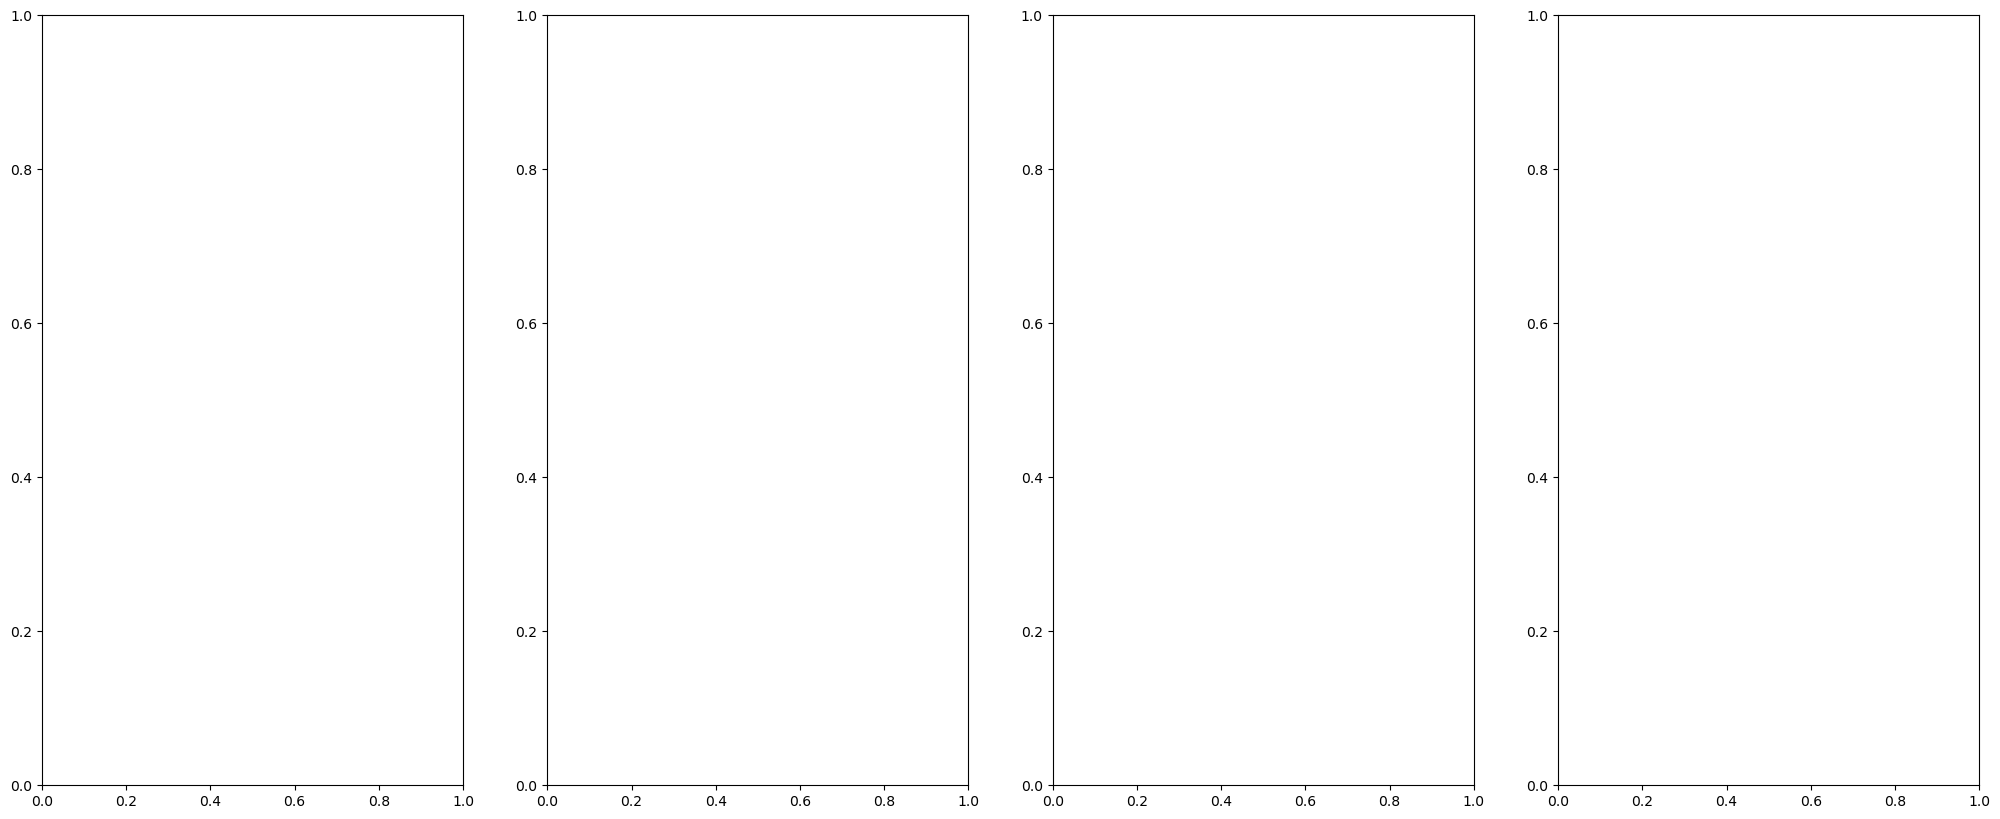

In [39]:
### 2D histogram ###

plt2, ax2 = mp.subplots(1,4,figsize=(25, 10)) # Ave plot of all cases

colors = ['black','skyblue','olive','coral']

for ic,case in enumerate(cases):

    fplot,vlong = pdf_data_proc(case,fdir0,vname,vscale) # Main variable
    fplotc,vlongc = pdf_data_proc(case,fdir0,vnamec,vscalec) # Always grab CONVECTIVE VARIABLE.
   
    

    ax2[ic].scatter(fplotc, fplot,color=colors[ic],alpha=0.1,marker='.',s=1)
    
#    ax2[ic].hist2d(fplotc, fplot, bins=(50, 50),range=([-50,10],[-20,50]))
    
    ax2[ic].vlines(0.,-60, 80, color='black',linestyle="dashed",lw=1)
    ax2[ic].hlines(0.,-60, 10, color='black',linestyle="dashed",lw=1)
    
    ax2[ic].set_title(cnames[ic],fontsize=24)
    ax2[ic].set_ylabel(vlong,fontsize=20) 
    ax2[ic].set_xlabel(vlongc,fontsize=15)
    ax2[ic].tick_params(axis='x', labelsize=16)
    ax2[ic].tick_params(axis='y', labelsize=16)
    
plt2.savefig('pdf_vres_scatter.png', dpi=100, bbox_inches='tight') 

In [16]:
def pdf_data_proc(case,fdir,vname,vscale,vtrange):
    
    ''' Routines to process input data for this case for plotting PDF '''
    
    print()
    print('CASE = ',case)
    
    
   
    ffile = fdir+case+'/atm/hist/'+case+'*h2a*2001-*nc'
    flist = sorted(glob.glob(ffile))
    fhist =  xr.open_mfdataset(flist)  
    fhist = fhist.sel(time=slice(vtrange[0], vtrange[1]))
    
    fvar = fhist[vname]
    vlong =  fvar.attrs['long_name']    
    fvar = vscale*fvar
    
    
    print(ffile)
    
    
# Is PRECC on same file as variable? If not read in different stream.

    two_streams = False if 'PRECC' in fhist.variables else True
    
    if two_streams :
        
        ffile = fdir+case+'/atm/hist/'+case+'*h3*1979-01*nc'
        flist = sorted(glob.glob(ffile))
        fhist =  xr.open_mfdataset(flist)  
        fhist = fhist.sel(time=slice(vtrange[0], vtrange[1]))
                   
        
    print(ffile)
    


        
## Variable masking ##
## Lowest level of a 3D variable
    
    if (vname == 'PRECC'):
        fvar = fprecc
    else:
        fvar = fvar[:,-1,:,:]
        
# Mask
    fvar = fvar.where(fprecc > 1.)
    
# 1d-ize
    pvar_1d = fvar.values.ravel()
    
    return pvar_1d,vlong